In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('/content/anemia.csv')

# **EDA**

In [4]:
df.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


In [6]:
df.describe()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.412738,22.905630,30.251232,85.523786,0.436312
std,0.499745,1.974546,3.969375,1.400898,9.636701,0.496102
min,0.000000,6.600000,16.000000,27.800000,69.400000,0.000000
25%,0.000000,11.700000,19.400000,29.000000,77.300000,0.000000
50%,1.000000,13.200000,22.700000,30.400000,85.300000,0.000000
75%,1.000000,15.000000,26.200000,31.400000,94.200000,1.000000
max,1.000000,16.900000,30.000000,32.500000,101.600000,1.000000


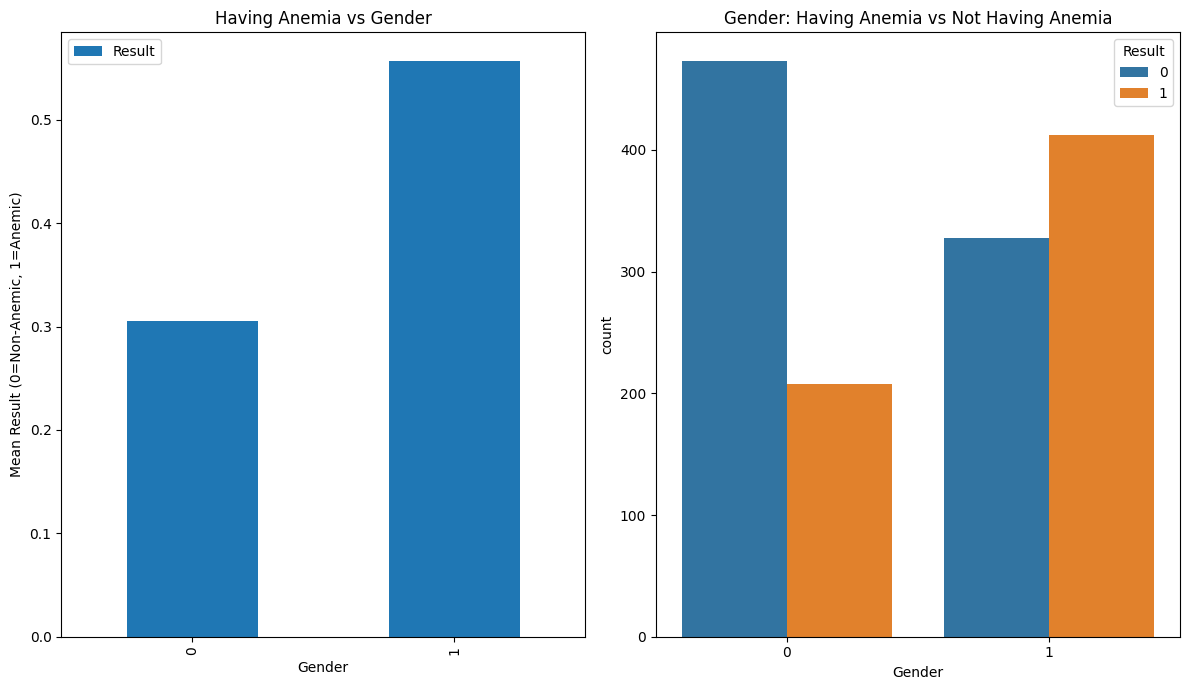

In [7]:
f, ax = plt.subplots(1, 2, figsize=(12,7))
df[['Gender', 'Result']].groupby(['Gender']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Having Anemia vs Gender')
ax[0].set_ylabel('Mean Result (0=Non-Anemic, 1=Anemic)')
sns.countplot(x='Gender', hue='Result', data=df, ax=ax[1])
ax[1].set_title('Gender: Having Anemia vs Not Having Anemia')
plt.tight_layout()
plt.show()

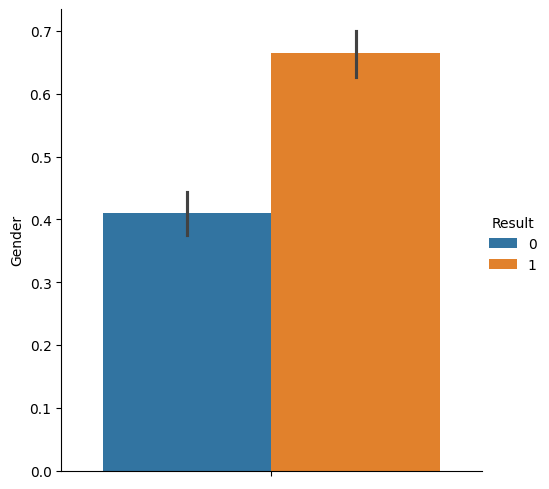

In [8]:
sns.catplot(y='Gender',hue='Result',kind='bar',data=df)
plt.show()

In [9]:
print('The highest hemoglobin was of:',df['Hemoglobin'].max())
print('The lowest hemoglobin was of:',df['Hemoglobin'].min())
print('The average hemoglobin in the data:',df['Hemoglobin'].mean())

The highest hemoglobin was of: 16.9
The lowest hemoglobin was of: 6.6
The average hemoglobin in the data: 13.412737508796623


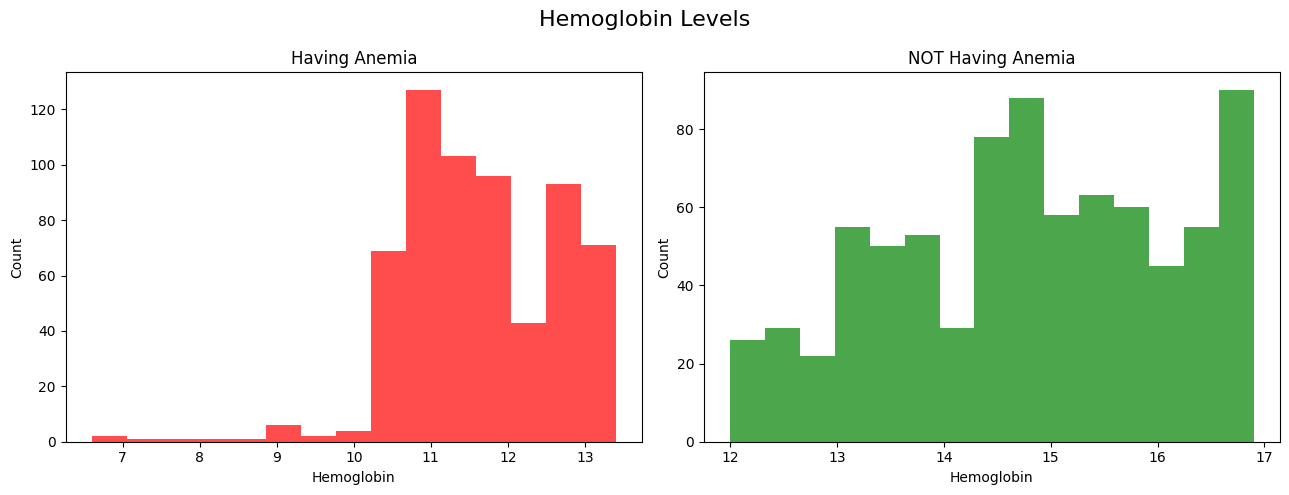

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
ax1.hist(df[df['Result']==1]['Hemoglobin'], bins=15, color='red', alpha=0.7)
ax1.set_title('Having Anemia')
ax1.set_xlabel('Hemoglobin')
ax1.set_ylabel('Count')
ax2.hist(df[df['Result']==0]['Hemoglobin'], bins=15, color='green', alpha=0.7)
ax2.set_title('NOT Having Anemia')
ax2.set_xlabel('Hemoglobin')
ax2.set_ylabel('Count')

fig.suptitle('Hemoglobin Levels', fontsize=16)
plt.tight_layout()
plt.show()


In [11]:
print('The highest MCH was of:',df['MCH'].max())
print('The lowest MCH was of:',df['MCH'].min())
print('The average MCH in the data:',df['MCH'].mean())

The highest MCH was of: 30.0
The lowest MCH was of: 16.0
The average MCH in the data: 22.90562983814215


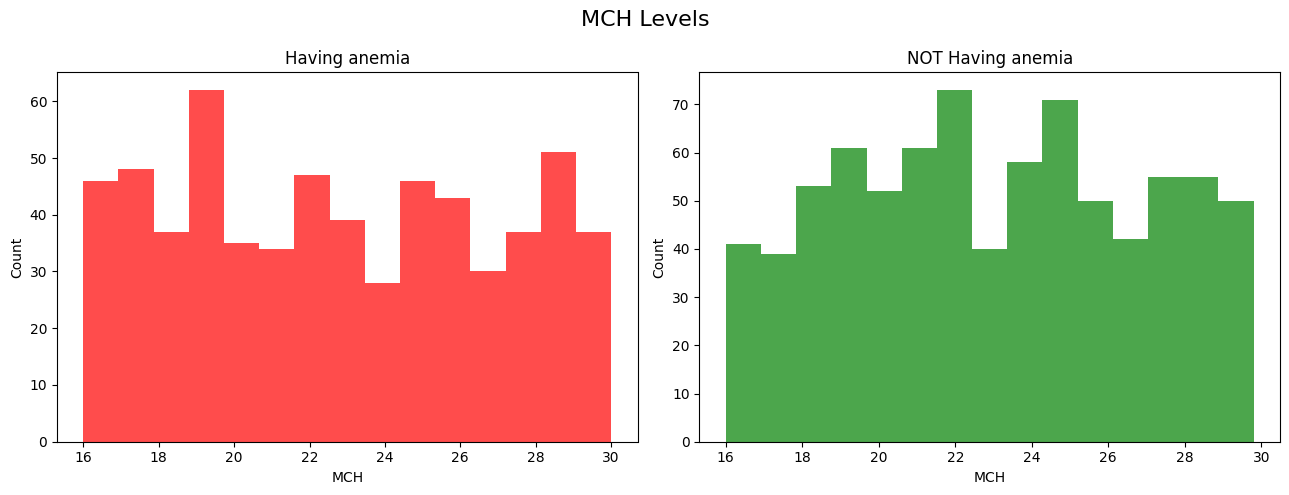

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
ax1.hist(df[df['Result']==1]['MCH'], bins=15, color='red', alpha=0.7)
ax1.set_title('Having anemia')
ax1.set_xlabel('MCH')
ax1.set_ylabel('Count')
ax2.hist(df[df['Result']==0]['MCH'], bins=15, color='green', alpha=0.7)
ax2.set_title('NOT Having anemia')
ax2.set_xlabel('MCH')
ax2.set_ylabel('Count')
fig.suptitle('MCH Levels', fontsize=16)
plt.tight_layout()
plt.show()


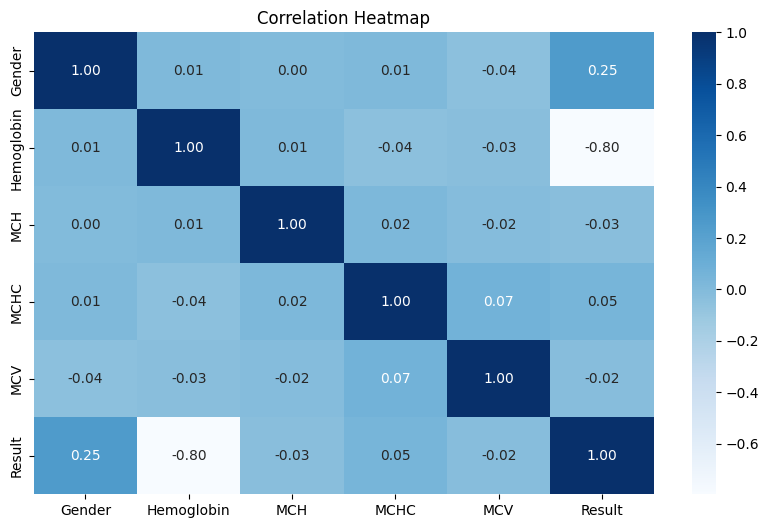

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

/tmp/ipython-input-319403074.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette="viridis")


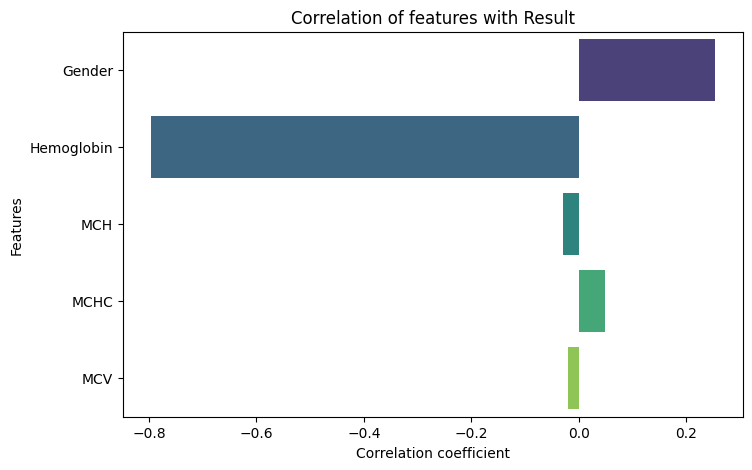

In [15]:
target = "Result"
corr = df.corr()[target].drop(target)
plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index, palette="viridis")
plt.title(f"Correlation of features with {target}")
plt.xlabel("Correlation coefficient")
plt.ylabel("Features")
plt.show()

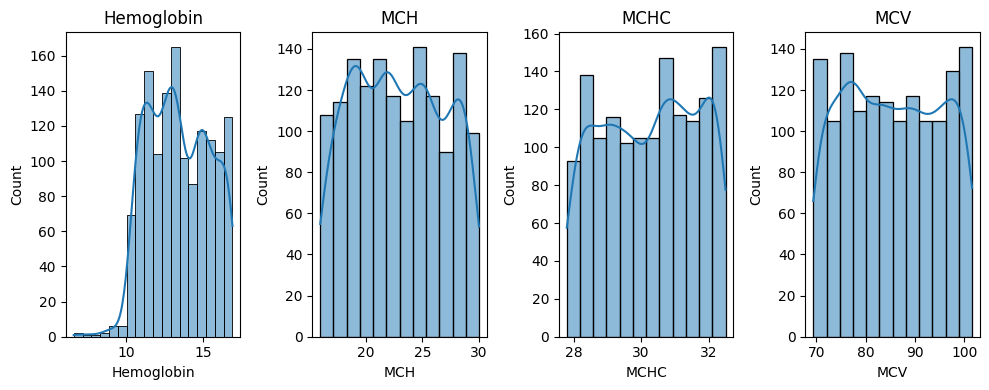

In [16]:
fig,axes=plt.subplots(1,4,figsize=(10,4))
axes=axes.flatten()
for index,col in enumerate(df.drop(['Gender','Result'],axis=1).columns):
  sns.histplot(data=df,x=col,ax=axes[index],kde=True)
  axes[index].set_title(col)
plt.tight_layout()
plt.show()

# **Data Cleaning**

In [17]:
for col in df.columns:
  col_unique=df[col].unique()
  print(f"{col} : {df[col].unique()}")
  print('-'*60)


Gender : [1 0]
------------------------------------------------------------
Hemoglobin : [14.9 15.9  9.  14.7 11.6 12.7 14.1 13.  16.7 13.4 14.  12.3 15.4 13.6
 16.5 16.2  6.9 11.8 11.  10.7 14.8 12.1 11.2 14.3 11.9 13.5 12.5 14.5
 12.8 15.2 16.1 11.7 11.3 15.3 14.4 13.1 16.9 13.8 10.8 12.4 16.4 10.4
 11.5 11.1 16.3 13.7 16.6 13.2 16.8 10.9 16.  11.4 12.9 15.5 13.3 12.2
 12.6 13.9 15.8 14.6 15.7 15.6 12.  10.5 15.  10.3 10.6  6.6 10.   8.9
  9.2  9.9  9.6  8.4  9.8  9.1  7.8  8.6  7.5 14.2 15.1]
------------------------------------------------------------
MCH : [22.7 25.4 21.5 16.  22.  22.3 19.5 28.5 29.7 25.8 18.3 27.5 25.2 28.9
 24.3 25.5 24.  21.8 24.6 19.3 17.2 28.1 16.3 26.  21.3 23.4 28.3 16.1
 16.4 24.1 17.  29.5 22.1 17.6 29.1 19.4 23.5 24.9 21.2 21.4 26.3 20.8
 26.7 18.6 19.1 28.2 20.  27.3 16.8 20.9 23.  18.7 29.6 26.1 22.8 27.1
 28.6 17.1 23.6 18.5 20.2 29.8 19.  21.6 19.2 26.4 20.6 30.  28.8 27.
 21.  27.6 27.4 16.9 24.8 20.3 18.4 20.4 25.6 21.9 28.7 25.3 24.2 22.9
 27.9 1

In [18]:
df.duplicated().sum()

np.int64(887)

In [19]:
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True,drop=1)

In [20]:
df.isnull().sum()

,0
Gender,0
Hemoglobin,0
MCH,0
MCHC,0
MCV,0
Result,0


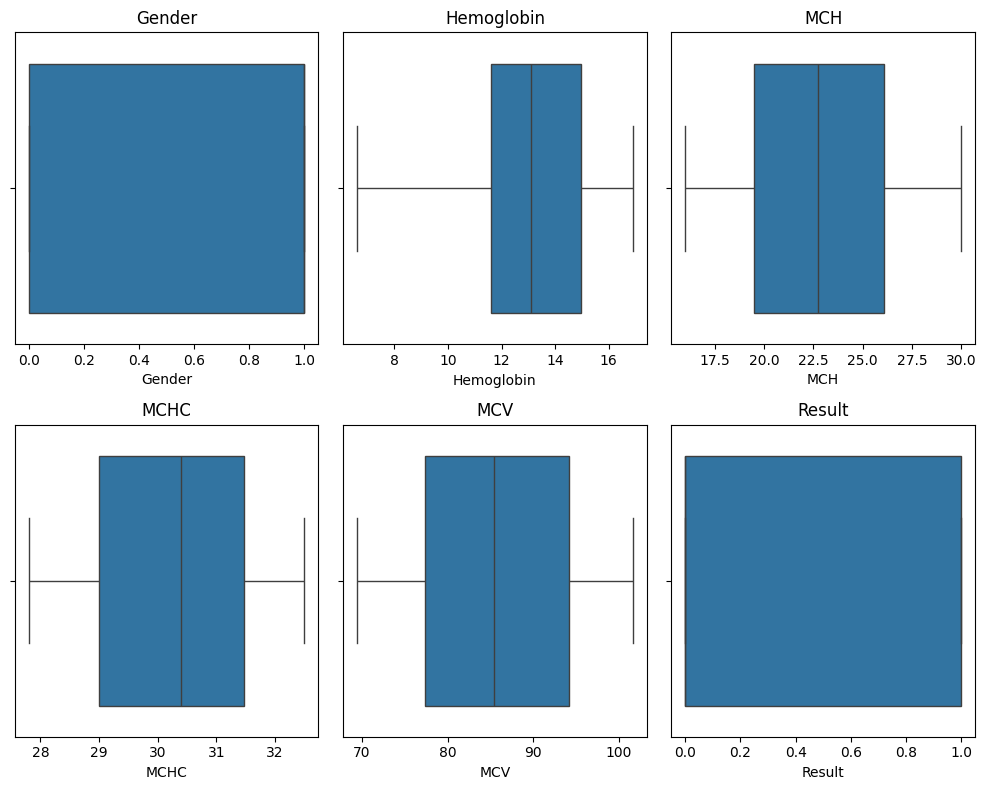

In [21]:
def box_plot():
  fig,axes=plt.subplots(2,3,figsize=(10,8))
  axes=axes.flatten()
  for index,col in enumerate(df.columns):
    sns.boxplot(data=df,x=col,ax=axes[index])
    axes[index].set_title(col)
  plt.tight_layout()
  plt.show()
box_plot()

In [22]:
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
IQR = q3 - q1
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR
outliers = ((df < lower) | (df > upper)).any(axis=1)
print(f'Number of rows with outliers before capping : {df[outliers].shape[0]}')



Number of rows with outliers before capping : 0


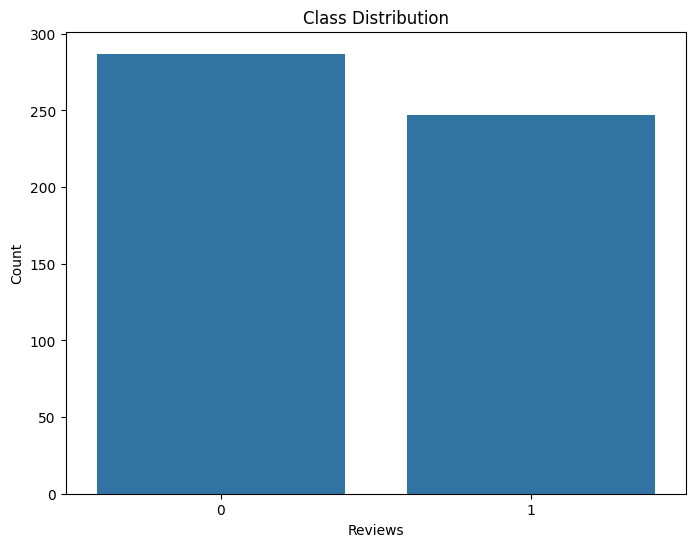

In [23]:

class_count = df['Result'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=class_count.index, y=class_count.values)
plt.title("Class Distribution")
plt.xlabel("Reviews")
plt.ylabel("Count")
plt.show()


# **Split Data**

In [24]:
X=df.drop('Result',axis=1)
y=df['Result']


In [25]:
sc = StandardScaler()
X= sc.fit_transform(X)

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import joblib

models = {
    "KNN Classifier": KNeighborsClassifier(n_neighbors=13),
    "Improved Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5, min_samples_split=5, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Improved Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=10, min_samples_split=10),
    "SVM": SVC(kernel='rbf', C=1, probability=True),  
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred, average='weighted')
    train_rec = recall_score(y_train, y_train_pred, average='weighted')
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')

    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average='weighted')
    test_rec = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    print(f"{name}:")
    print(f" Train -> Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f}, F1: {train_f1:.4f}")
    print(f" Test  -> Acc: {test_acc:.4f}, Prec: {test_prec:.4f}, Rec: {test_rec:.4f}, F1: {test_f1:.4f}")
    print("-"*60)




KNN Classifier:
 Train -> Acc: 0.9651, Prec: 0.9656, Rec: 0.9651, F1: 0.9652
 Test  -> Acc: 0.9255, Prec: 0.9302, Rec: 0.9255, F1: 0.9255
------------------------------------------------------------
Improved Random Forest:
 Train -> Acc: 0.9973, Prec: 0.9973, Rec: 0.9973, F1: 0.9973
 Test  -> Acc: 1.0000, Prec: 1.0000, Rec: 1.0000, F1: 1.0000
------------------------------------------------------------
Logistic Regression:
 Train -> Acc: 0.9866, Prec: 0.9870, Rec: 0.9866, F1: 0.9866
 Test  -> Acc: 0.9689, Prec: 0.9709, Rec: 0.9689, F1: 0.9690
------------------------------------------------------------
Improved Decision Tree:
 Train -> Acc: 1.0000, Prec: 1.0000, Rec: 1.0000, F1: 1.0000
 Test  -> Acc: 1.0000, Prec: 1.0000, Rec: 1.0000, F1: 1.0000
------------------------------------------------------------
SVM:
 Train -> Acc: 0.9866, Prec: 0.9870, Rec: 0.9866, F1: 0.9866
 Test  -> Acc: 0.9627, Prec: 0.9655, Rec: 0.9627, F1: 0.9628
--------------------------------------------------------